County Features vs Nuclear Plant Locations Map

In [1]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from shapely.geometry import Point

import json

In [2]:
base = Path.cwd().parent

df = pd.read_csv(base / 'processed_data' / 'final_dataset.csv')
counties = gpd.read_file(base / 'processed_data' / 'county_boundaries.geojson')
plants_raw = pd.read_csv(base / 'processed_data' / 'nuclear_plants_cleaned.csv')

In [3]:
df['population'] = df['population'].str.replace(',', '').astype(float)

# pad to 5 chars so the join doesn't silently drop leading zeros
df['geo_id'] = df['geo_id'].astype(str).str.zfill(5)
counties['geoid'] = counties['geoid'].astype(str).str.zfill(5)
plants_raw['geo_id'] = plants_raw['geo_id'].astype(str).str.zfill(5)

# drop alaska/hawaii so the map doesn't look squished
exclude_fips = {'02', '15'}
counties_conus = counties[~counties['state_fips'].isin(exclude_fips)].copy()

In [4]:
# tried merging on county_name first -- doesn't work, names repeat across states
gdf = counties_conus.merge(df, left_on='geoid', right_on='geo_id', how='left')
print(gdf.shape)
gdf.head(2)

(3200, 40)


,geoid,state_fips,county_fips,state_abbr,county_name_x,county_name_full,area_land_sqm,area_water_sqm,lat,lon,...,total_rivers_mile,military_count,total_military_area_m,pct_military,plant_count,pga_max,distance_to_lines_km,transmission_lines_count,max_voltage,average_voltage
0,31039,31,039,NM,Cuming,Cuming County,1477563029,10772508,+41.9158651,-096.7885168,...,427.75,0.0,0.0,0.0,0.0,0.052,21.248423,1.0,115.0,115.0
1,53069,53,069,None,Wahkiakum,Wahkiakum County,680980771,61564427,+46.2946377,-123.4244583,...,89.88,0.0,0.0,0.0,0.0,0.690,14.855808,0.0,0.0,0.0


In [5]:
# using county centroids as plant locations
# TODO: swap in actual plant lat/lon coordinates if we can find them
plant_geoids = set(plants_raw['geo_id'])
plant_counties = counties_conus[counties_conus['geoid'].isin(plant_geoids)].copy()
plant_points = gpd.GeoDataFrame(
    plant_counties,
    geometry=[Point(r['lon'], r['lat']) for _, r in plant_counties.iterrows()],
    crs='EPSG:4326'
)

In [6]:
# first version used ax.scatter() on lat/lon -- didn't align with the gdf projection
# gdf.plot(...); ax.scatter(plant_lons, plant_lats, ...)

def plot_feature_map(gdf, column, title, cmap='RdPu', plant_gdf=None):
    """Choropleth of one county-level feature with nuclear plant sites overlaid."""
    fig, ax = plt.subplots(figsize=(22, 12))

    gdf.plot(
        column=column,
        ax=ax,
        cmap=cmap,
        legend=True,
        missing_kwds={'color': 'lightgray', 'label': 'no data'},
        legend_kwds={'shrink': 0.45, 'label': column}
    )

    if plant_gdf is not None:
        plant_gdf.plot(ax=ax, color='hotpink', markersize=22, marker='^', zorder=5)
        plant_marker = mpatches.Patch(color='hotpink', label='nuclear plant county')
        ax.legend(handles=[plant_marker], loc='lower left', fontsize=9)

    ax.set_xlim(-125, -65)
    ax.set_ylim(24, 50)
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

### Seismic risk

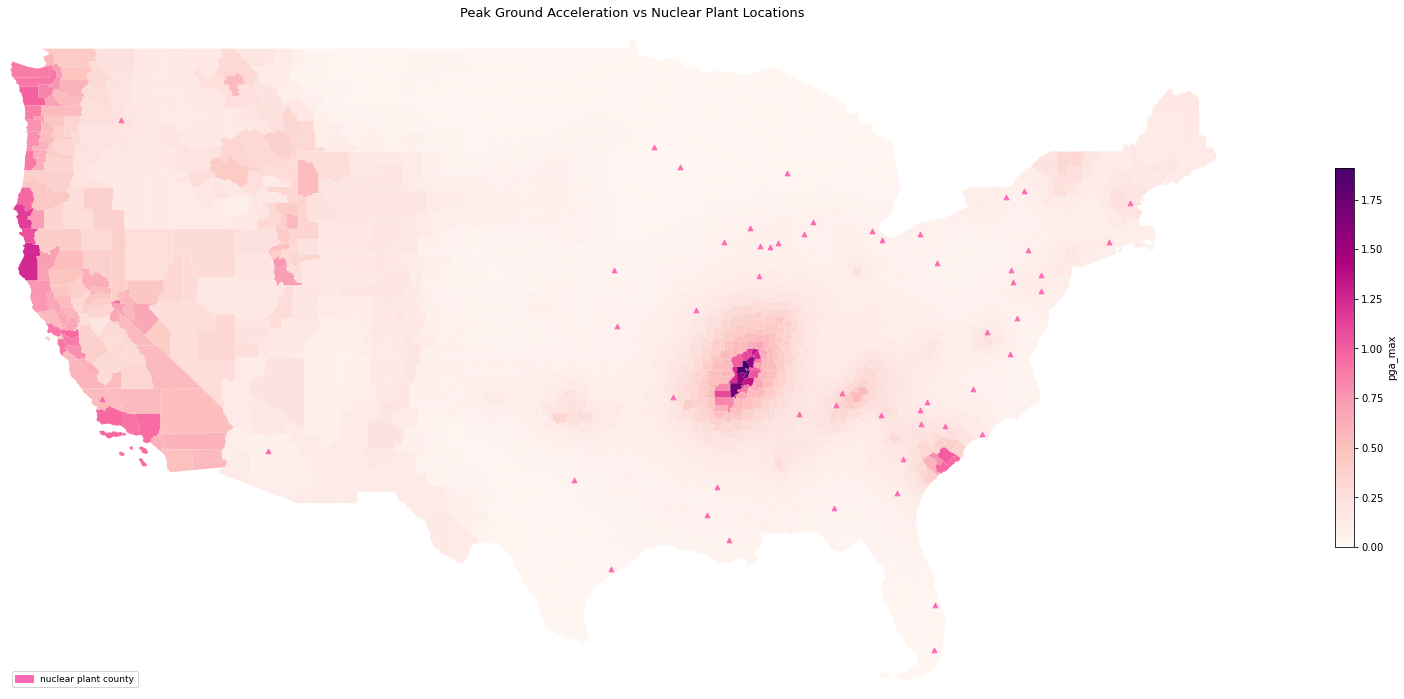

In [7]:
plot_feature_map(gdf, 'pga_max', 'Peak Ground Acceleration vs Nuclear Plant Locations', cmap='RdPu', plant_gdf=plant_points)

### Transmission line density

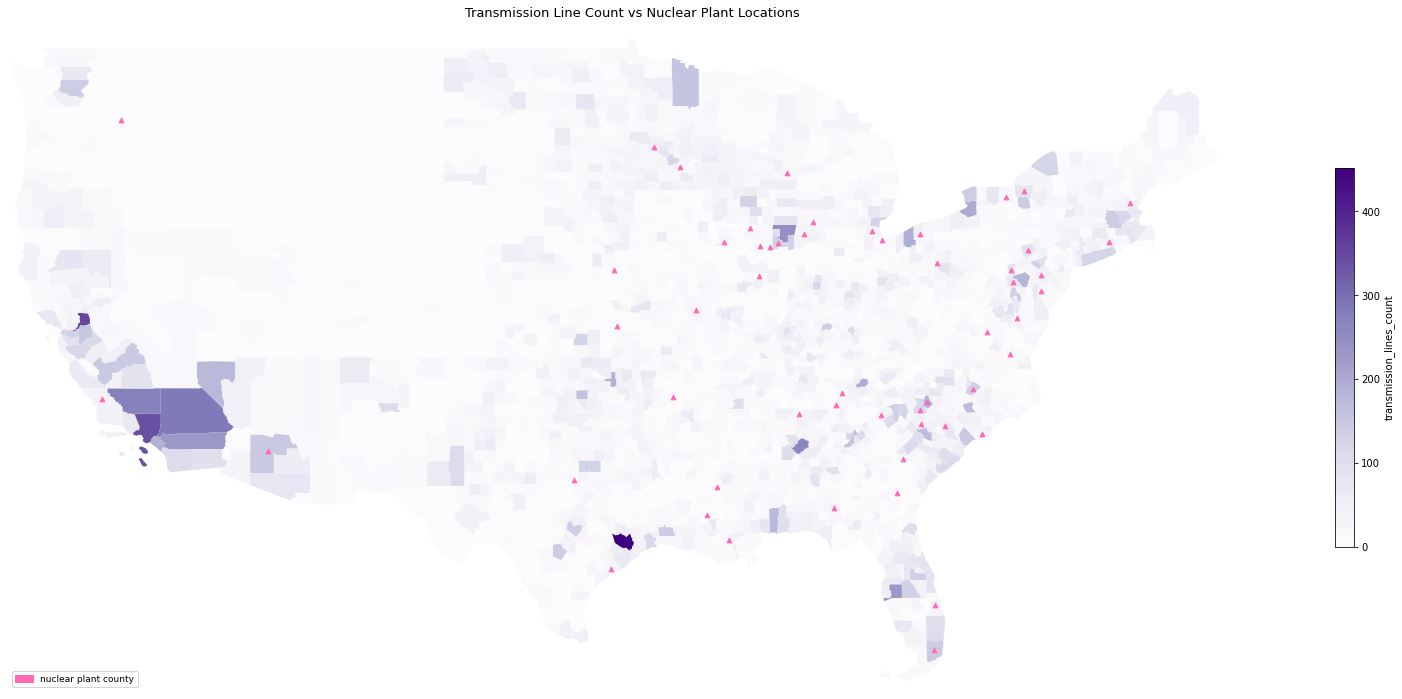

In [8]:
plot_feature_map(gdf, 'transmission_lines_count', 'Transmission Line Count vs Nuclear Plant Locations', cmap='Purples', plant_gdf=plant_points)

### Flood risk

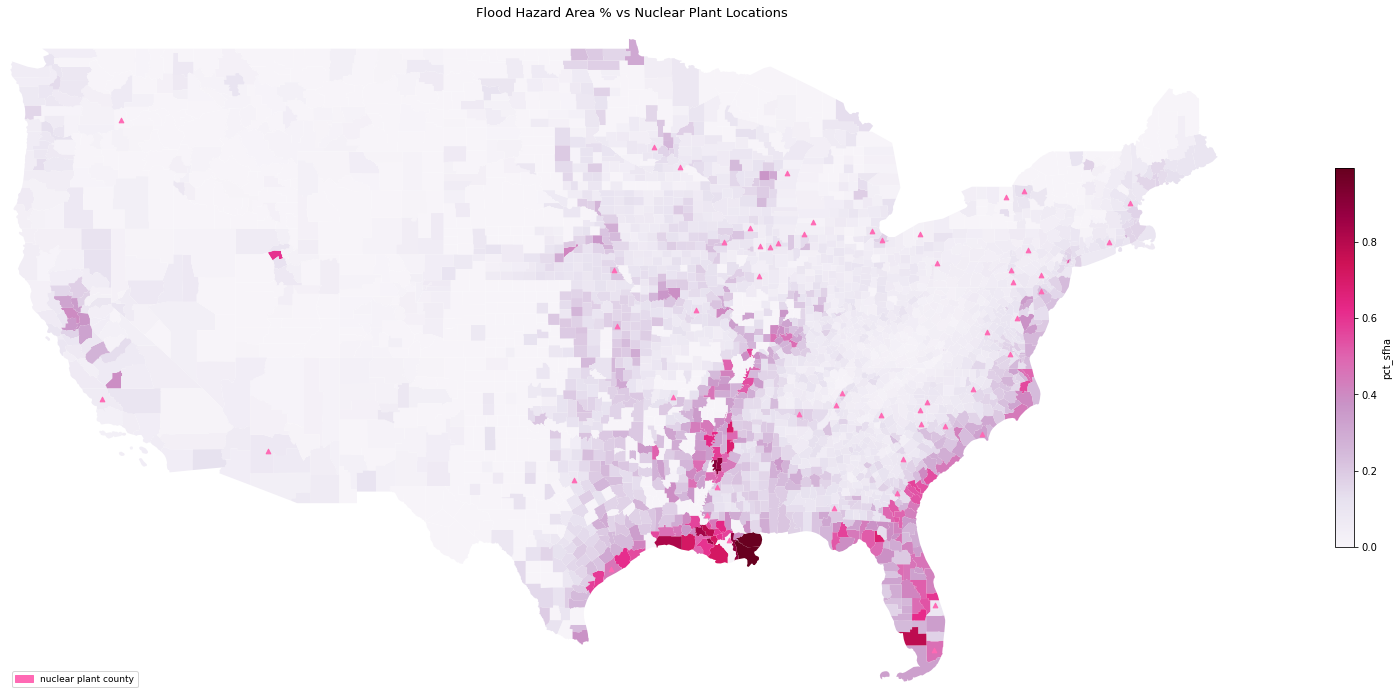

In [9]:
plot_feature_map(gdf, 'pct_sfha', 'Flood Hazard Area % vs Nuclear Plant Locations', cmap='PuRd', plant_gdf=plant_points)

### Energy consumption

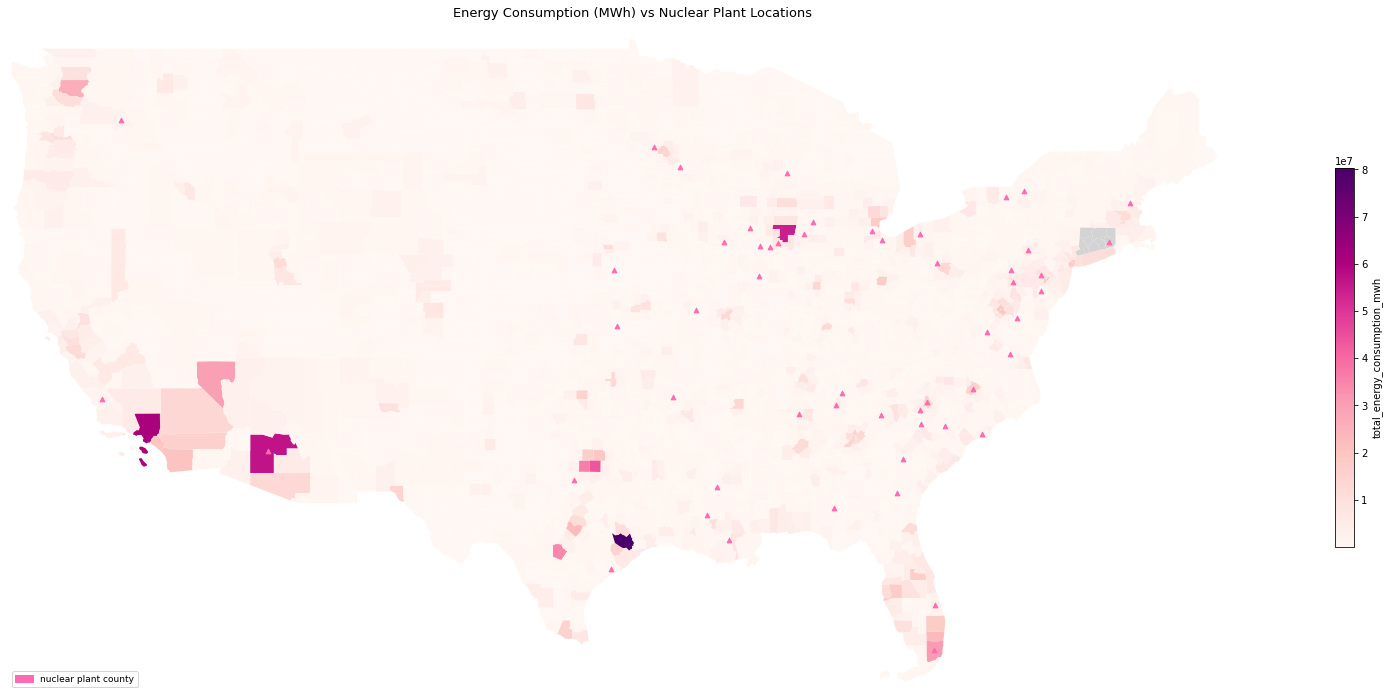

In [10]:
plot_feature_map(gdf, 'total_energy_consumption_mwh', 'Energy Consumption (MWh) vs Nuclear Plant Locations', cmap='RdPu', plant_gdf=plant_points)

### River proximity

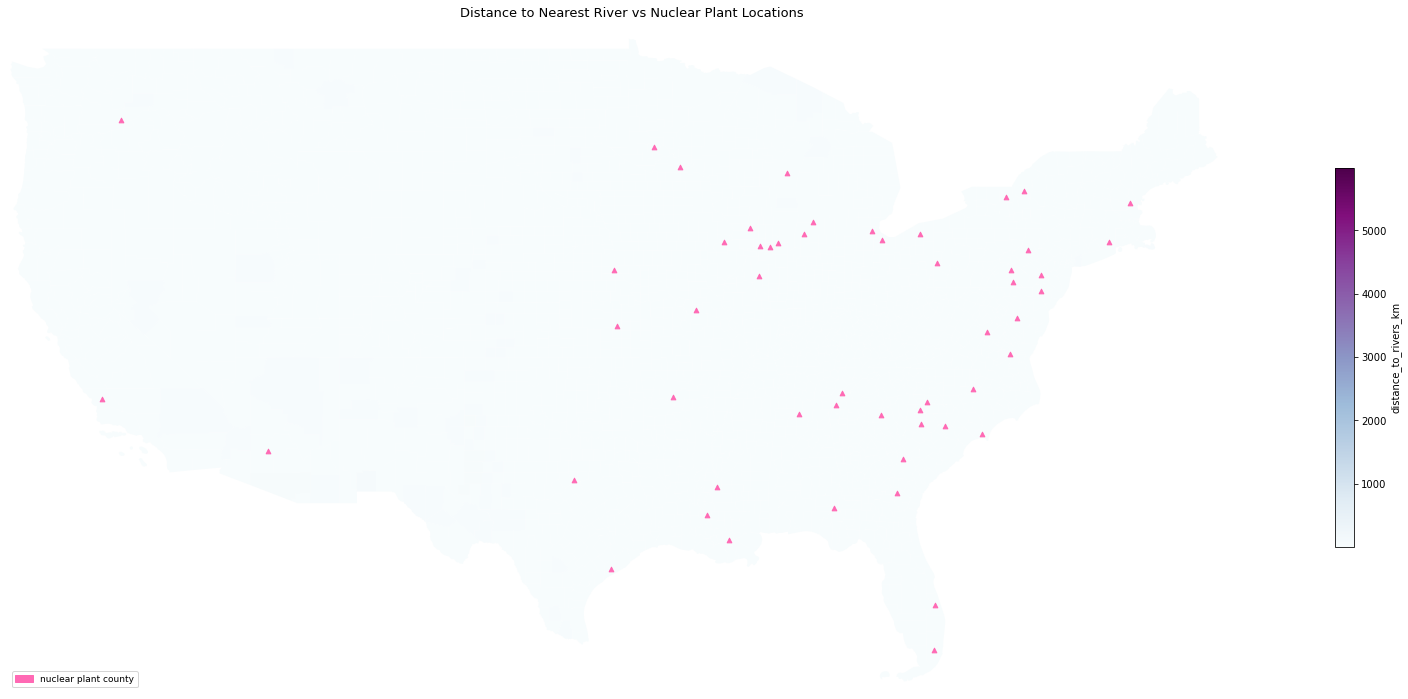

In [11]:
# lower = closer to a river
plot_feature_map(gdf, 'distance_to_rivers_km', 'Distance to Nearest River vs Nuclear Plant Locations', cmap='BuPu', plant_gdf=plant_points)

### All features side by side

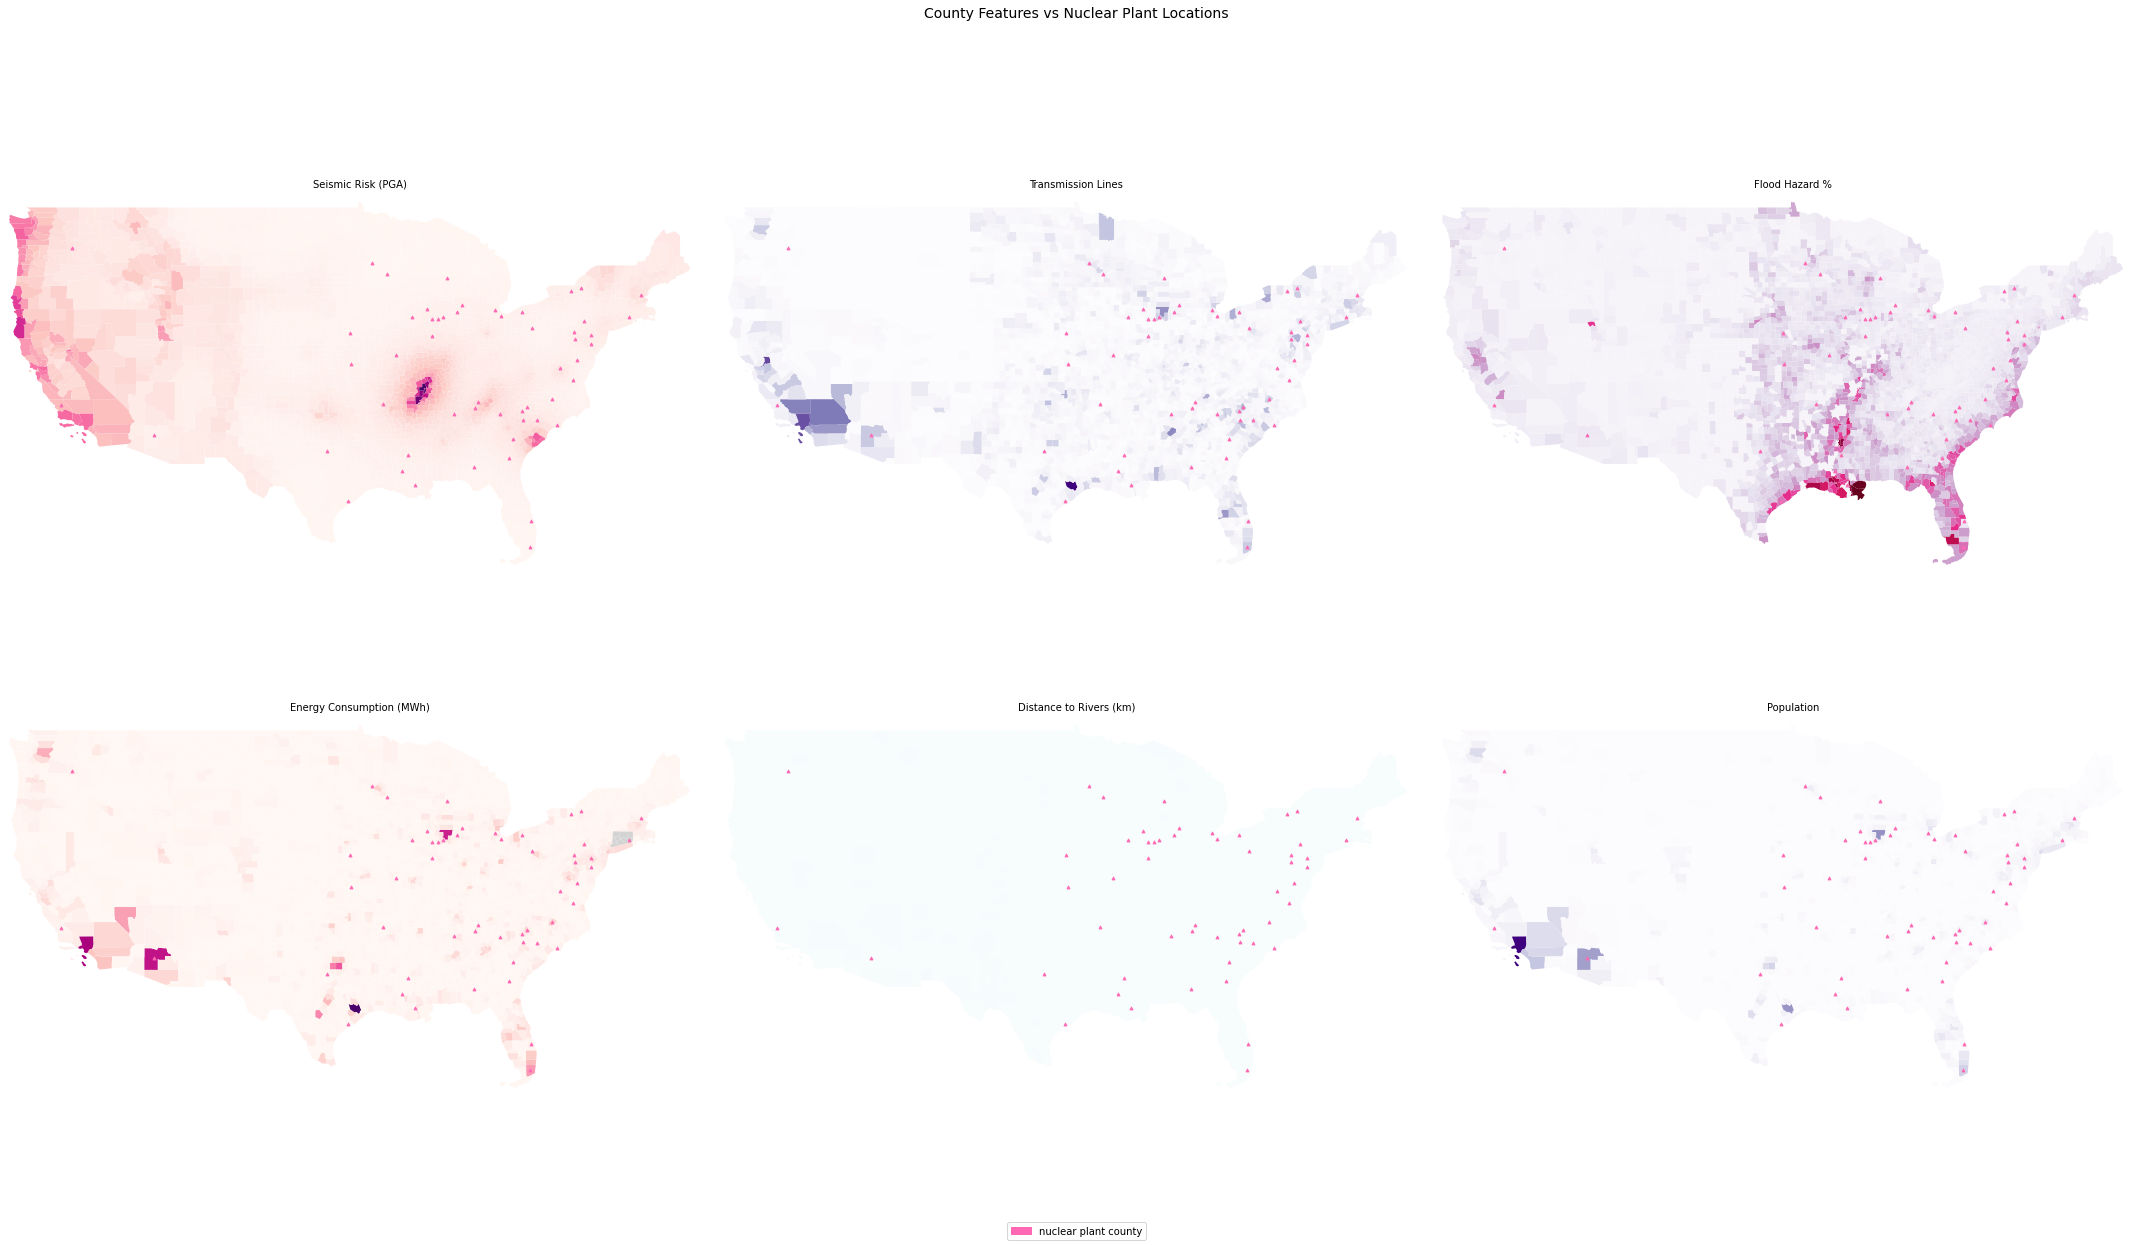

In [12]:
# quick version to see everything at once
features = [
    ('pga_max',                    'Seismic Risk (PGA)',          'RdPu'),
    ('transmission_lines_count',   'Transmission Lines',          'Purples'),
    ('pct_sfha',                   'Flood Hazard %',              'PuRd'),
    ('total_energy_consumption_mwh','Energy Consumption (MWh)',   'RdPu'),
    ('distance_to_rivers_km',      'Distance to Rivers (km)',     'BuPu'),
    ('population',                 'Population',                  'Purples'),
]

fig, axes = plt.subplots(2, 3, figsize=(30, 17))
axes = axes.flatten()

for i, (col, title, cmap) in enumerate(features):
    ax = axes[i]
    gdf.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        legend=False,
        missing_kwds={'color': 'lightgray'}
    )
    plant_points.plot(ax=ax, color='hotpink', markersize=8, marker='^', zorder=5)
    ax.set_xlim(-125, -65)
    ax.set_ylim(24, 50)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()

plant_marker = mpatches.Patch(color='hotpink', label='nuclear plant county')
fig.legend(handles=[plant_marker], loc='lower center', fontsize=10, ncol=1)
plt.suptitle('County Features vs Nuclear Plant Locations', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()